Import des données

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

from fonctions import beau_tableau
from fonctions import top_surrepresentation
from fonction import score_candidat

df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb' 
)

ImportError: cannot import name 'top_surrepresentation' from 'fonctions' (/home/onyxia/work/python2A/fonctions.py)

1 Exploration générale

Question 1

In [ ]:
# Ajouter des zéros devant l'ancien code commune
df["code_commune"] = df["code_commune"].astype(str).str.zfill(3)

# Coller le code département et l'ancien code commune
df["code_commune"] = df["code_departement"] + df["code_commune"]

# Nouvelle colonne prénom NOM
df["candidat"] =  df["prenom"] + " " + df["nom"]
print(df)

       code_departement              libelle_departement    code_commune  \
0                    01                              Ain           01001   
1                    01                              Ain           01002   
2                    01                              Ain           01004   
3                    01                              Ain           01005   
4                    01                              Ain           01006   
...                 ...                              ...             ...   
528670      fr_etranger  Français établis hors de France  fr_etranger229   
528671      fr_etranger  Français établis hors de France  fr_etranger231   
528672      fr_etranger  Français établis hors de France  fr_etranger233   
528673      fr_etranger  Français établis hors de France  fr_etranger234   
528674      fr_etranger  Français établis hors de France  fr_etranger235   

                libelle_commune    prenom      nom  voix          candidat  
0       L'

Question 2

In [ ]:
# Liste des candidats sans votes nuls
liste_candidat = df["candidat"].dropna().unique()

# Nombre candidats
candidat = len(liste_candidat)

# Affichage du nombre de candidats
print(f"En 2022, il y avait {candidat} candidats à l'élection présidentielle.")

En 2022, il y avait 12 candidats à l'élection présidentielle.


Question 3

In [ ]:
score_national = (df.groupby("candidat").agg({'voix': sum}).reset_index().sort_values('voix', ascending = False))

score_national["Score (% votes exprimés)"] = score_national["voix"] / score_national["voix"].sum() * 100
score_national.rename(columns={'voix': 'Nombre votes (total)'}, inplace=True)   

affichage = beau_tableau(score_national, "Résultats du premier tour des élections présidentielles 2022")
affichage

/tmp/ipykernel_8968/2308706894.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  score_national = (df.groupby("candidat").agg({'voix': sum}).reset_index().sort_values('voix', ascending = False))


GT(_tbl_data=                 candidat  Nombre votes (total)  Score (% votes exprimés)
1         Emmanuel MACRON               9783058                 27.845822
5           Marine LE PEN               8133828                 23.151568
4      Jean-Luc MÉLENCHON               7712520                 21.952386
11           Éric ZEMMOUR               2485226                  7.073776
9        Valérie PÉCRESSE               1679001                  4.778993
10          Yannick JADOT               1627853                  4.633409
3           Jean LASSALLE               1101387                  3.134912
2          Fabien ROUSSEL                802422                  2.283959
7   Nicolas DUPONT-AIGNAN                725176                  2.064091
0            Anne HIDALGO                616478                  1.754701
8         Philippe POUTOU                268904                  0.765390
6        Nathalie ARTHAUD                197094                  0.560995, _body=<great_tables._gt_data.Body object at 0x7f1c0b737820>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='candidat', column_align='center', column_width=None), ColInfo(var='Nombre votes (total)', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='center', column_width=None), ColInfo(var='Score (% votes exprimés)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f1c0b3d2490>, _spanners=Spanners([]), _heading=Heading(title=Html(text='<b>Résultats du premier tour des élections présidentielles 2022</b>'), subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f1c0b3d2ad0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f1c0b7375c0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f1c0b3d2c10>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f1c0b3d2fd0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='14px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='3px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#444444'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsIn

Question 4

In [ ]:
# Calcul du nombre de voix des candidats pour chaque département
score_departements = (
    df.groupby(["candidat", "code_departement"])
    .agg({'voix': 'sum'})
    .reset_index()
    .sort_values(
        by=['code_departement', 'voix'], # trie par département et nombre de voix
        ascending=[True, False]
    )
    )

# Calcul du score
score_departements["Score (% votes exprimés)"] = round(
    (
    (score_departements["voix"] /
     score_departements.groupby("code_departement")["voix"]
     .transform("sum") #  somme pour chacun des candidats de chacun des départements
     ) * 100
    ), 2
)

score_departements.rename(columns={'voix': 'votes'}, inplace=True)

Test pour le département de l'Aude (11)

In [ ]:
score_departement_11 = score_departements[score_departements["code_departement"] == '11']
print(score_departement_11)

                   candidat code_departement  votes  Score (% votes exprimés)
550           Marine LE PEN               11  64027                     30.14
118         Emmanuel MACRON               11  43104                     20.29
442      Jean-Luc MÉLENCHON               11  42039                     19.79
1198           Éric ZEMMOUR               11  18434                      8.68
334           Jean LASSALLE               11  12382                      5.83
982        Valérie PÉCRESSE               11   7350                      3.46
1090          Yannick JADOT               11   6322                      2.98
10             Anne HIDALGO               11   6166                      2.90
226          Fabien ROUSSEL               11   5622                      2.65
766   Nicolas DUPONT-AIGNAN               11   4206                      1.98
874         Philippe POUTOU               11   1748                      0.82
658        Nathalie ARTHAUD               11   1026             

Question 5

In [ ]:
# Renommer les variables
score_national.rename(columns={
    "Score (% votes exprimés)": "score_national"
}, inplace=True)
score_national.rename(columns={
    "Nombre votes (total)": "vote_national"
}, inplace=True)

score_departements.rename(columns={
    "votes": "vote_departement"
}, inplace=True)
score_departements.rename(columns={
    "Score (% votes exprimés)": "score_departement"
}, inplace=True)

# Jointure
score_joint = score_departements.merge(
    score_national,
    on="candidat",
    how="left"
)

Test pour le département de l'Aude (11)

In [ ]:
score_joint_11 = score_joint[
    score_joint["code_departement"] == "11"
]

print(score_joint_11)

                  candidat code_departement  vote_departement  \
120          Marine LE PEN               11             64027   
121        Emmanuel MACRON               11             43104   
122     Jean-Luc MÉLENCHON               11             42039   
123           Éric ZEMMOUR               11             18434   
124          Jean LASSALLE               11             12382   
125       Valérie PÉCRESSE               11              7350   
126          Yannick JADOT               11              6322   
127           Anne HIDALGO               11              6166   
128         Fabien ROUSSEL               11              5622   
129  Nicolas DUPONT-AIGNAN               11              4206   
130        Philippe POUTOU               11              1748   
131       Nathalie ARTHAUD               11              1026   

     score_departement  vote_national  score_national  
120              30.14        8133828       23.151568  
121              20.29        9783058     

Question 6

In [ ]:
score_joint["surrepresentation (%)"] = round(
    (
        score_joint["score_departement"] /
        score_joint["score_national"] - 1
    ) * 100,
    2
)
print(score_joint)

                   candidat code_departement  vote_departement  \
0           Emmanuel MACRON               01             92206   
1             Marine LE PEN               01             86755   
2        Jean-Luc MÉLENCHON               01             57832   
3              Éric ZEMMOUR               01             27530   
4          Valérie PÉCRESSE               01             17572   
...                     ...              ...               ...   
1291  Nicolas DUPONT-AIGNAN      fr_etranger              7074   
1292          Jean LASSALLE      fr_etranger              5964   
1293         Fabien ROUSSEL      fr_etranger              3266   
1294        Philippe POUTOU      fr_etranger              3145   
1295       Nathalie ARTHAUD      fr_etranger              1300   

      score_departement  vote_national  score_national  surrepresentation (%)  
0                 27.69        9783058       27.845822                  -0.56  
1                 26.05        8133828       23

Question 7 : Test pour le top 5 de ZEMMOUR

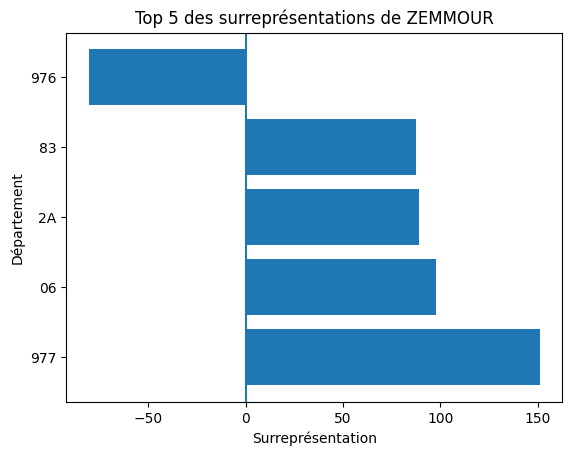

In [ ]:
top_surrepresentation(5, "ZEMMOUR", score_joint)

Question 8

In [ ]:
from cartiflette import carti_download

departement_borders = carti_download(
 values = ["France"],
 crs = 4326,
 borders = "DEPARTEMENT",
 vectorfile_format="geojson",
 simplification=50,
 filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
 source="EXPRESS-COG-CARTO-TERRITOIRE",
 year=2022)

In [ ]:
# Nom des colonnes
print("Colonnes IGN :", departement_borders.columns)
# Jointure à faire sue INSEE_DEP

# Jointure
carte_score = departement_borders.merge(
score_candidat("Marine LE PEN", score_joint), 
left_on="INSEE_DEP",   # nom sur la carte
right_on="code_departement", # score_departement
how="left"  
)

# Cartographie
carte_score.plot(column='surrepresentation (%)', 
legend=True,
cmap='RdBu_r',
legend_kwds={'label': "(% par rapport à la moyenne nationale)"},
edgecolor='black', 
linewidth=0.5)

# Titre
plt.title("Répartition des scores du candidat par département")
plt.show()

Colonnes IGN : Index(['INSEE_DEP', 'PAYS', 'LIBELLE_DEPARTEMENT', 'POPULATION', 'SOURCE',
       'geometry'],
      dtype='object')


TypeError: score_candidat() takes 1 positional argument but 2 were given

Test avec Marine LE PEN